
# Matrix Factorization Baseline - KuaiRec Dataset
Simple Matrix Factorization model for recommendations

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot, Add, Activation, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

In [2]:

# Load KuaiRec dataset
data_dir = '../data/kuairec_data'
ratings = pd.read_csv(f'{data_dir}/kuairec_combined.csv')

# Rename columns if needed
if 'user_id' in ratings.columns:
    ratings = ratings.rename(columns={'user_id': 'userId', 'video_id': 'itemId'})
if 'watch_ratio' in ratings.columns and 'rating' not in ratings.columns:
    ratings['rating'] = ratings['watch_ratio']

ratings = ratings[['userId', 'itemId', 'rating']]
print(f"Loaded {len(ratings)} interactions")
print(f"Users: {ratings['userId'].nunique()}, Items: {ratings['itemId'].nunique()}")

Loaded 12530806 interactions
Users: 7176, Items: 10728


In [3]:
# Normalize ratings to 0-1
scaler = MinMaxScaler()
ratings['rating'] = scaler.fit_transform(ratings[['rating']])

# Encode users and items
user_ids = ratings['userId'].unique()
item_ids = ratings['itemId'].unique()

user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {i: idx for idx, i in enumerate(item_ids)}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: it for it, i in item2idx.items()}

ratings['user'] = ratings['userId'].map(user2idx)
ratings['item'] = ratings['itemId'].map(item2idx)

num_users = len(user2idx)
num_items = len(item2idx)

print(f"Encoded: {num_users} users, {num_items} items")


Encoded: 7176 users, 10728 items


In [4]:
# User-wise split (80/20)
train_rows, test_rows = [], []

for user_id, user_data in ratings.groupby('user'):
    user_data = user_data.sample(frac=1, random_state=42)
    n = len(user_data)
    split = int(0.8 * n)
    train_rows.append(user_data.iloc[:split])
    if split < n:
        test_rows.append(user_data.iloc[split:])

train_df = pd.concat(train_rows)
test_df = pd.concat(test_rows)

X_train = [train_df['user'].values, train_df['item'].values]
X_test = [test_df['user'].values, test_df['item'].values]
y_train = train_df['rating'].values
y_test = test_df['rating'].values

print(f"Train: {len(train_df)}, Test: {len(test_df)}")


Train: 10021757, Test: 2509049


In [5]:

# Matrix Factorization model
latent_dim = 32

user_input = Input(shape=(1,))
item_input = Input(shape=(1,))

# Embeddings
user_emb = Embedding(num_users, latent_dim, embeddings_regularizer=l2(0.0001))(user_input)
item_emb = Embedding(num_items, latent_dim, embeddings_regularizer=l2(0.0001))(item_input)

# Biases
user_bias = Embedding(num_users, 1, embeddings_regularizer=l2(0.0001))(user_input)
item_bias = Embedding(num_items, 1, embeddings_regularizer=l2(0.0001))(item_input)

# Flatten
user_vec = Flatten()(user_emb)
item_vec = Flatten()(item_emb)
user_b = Flatten()(user_bias)
item_b = Flatten()(item_bias)

# Dot product + biases
dot = Dot(axes=1)([user_vec, item_vec])
output = Add()([dot, user_b, item_b])
output = Activation('sigmoid')(output)

model = Model([user_input, item_input], output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 32)     │    229,632 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 32)     │    343,296 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 1)      │      7,176 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 1)      │     10,728 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 1)         │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 1)         │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1)         │          0 │ dot[0][0],        │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1)         │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 590,832 (2.25 MB)

 Trainable params: 590,832 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:

# Train with callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("mf_kuairec_best_model.keras", save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 299s 8ms/step - loss: 0.1977 - mae: 0.3997 - val_loss: 0.1971 - val_mae: 0.3975
Epoch 2/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 445s 11ms/step - loss: 0.1971 - mae: 0.3975 - val_loss: 0.1971 - val_mae: 0.3974
Epoch 3/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 339s 9ms/step - loss: 0.1971 - mae: 0.3975 - val_loss: 0.1971 - val_mae: 0.3975
Epoch 4/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 439s 11ms/step - loss: 0.1971 - mae: 0.3975 - val_loss: 0.1970 - val_mae: 0.3974
Epoch 5/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 437s 11ms/step - loss: 0.1971 - mae: 0.3975 - val_loss: 0.1971 - val_mae: 0.3975
Epoch 6/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 445s 11ms/step - loss: 0.1971 - mae: 0.3975 - val_loss: 0.1970 - val_mae: 0.3975
Epoch 7/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 384s 10ms/step - loss: 0.1971 - mae: 0.3975 - val_loss: 0.1971 - val_mae: 0.3975
Epoch 8/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 371s 9ms/step - loss: 0.1971 - mae: 0.3975 - val_loss: 0.1970 - val_mae: 0.3975
Epo

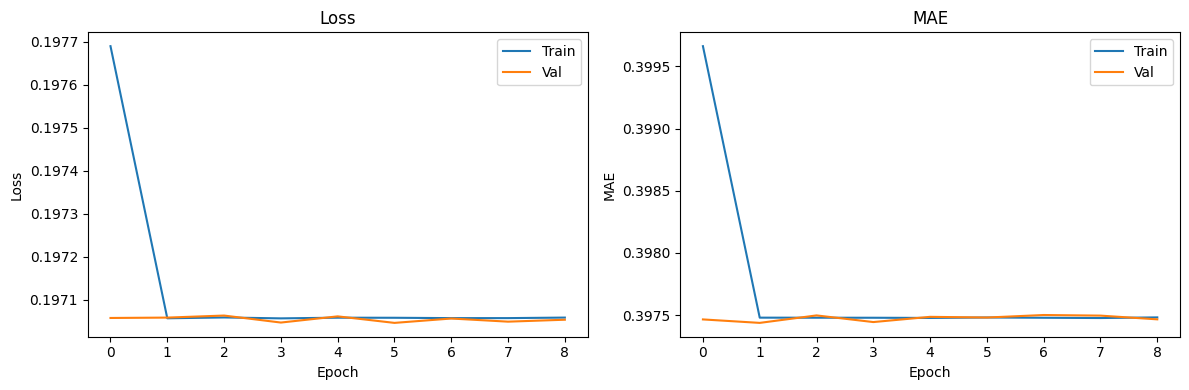

In [7]:
# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train')
plt.plot(history.history['val_mae'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('MAE')

plt.tight_layout()
plt.show()


In [8]:

# Evaluate model
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
y_pred = model.predict(X_test, verbose=0).flatten()
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("="*50)
print("RESULTS")
print("="*50)
print(f"MSE: {test_loss:.6f}")
print(f"MAE: {test_mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print("="*50)

# Save metrics
import os
os.makedirs("../results", exist_ok=True)
with open("../results/metrics_kuairec_mf.txt", "w") as f:
    f.write(f"MSE: {test_loss:.6f}\nMAE: {test_mae:.6f}\nRMSE: {rmse:.6f}\n")
print("\nMetrics saved!")

RESULTS
MSE: 0.197047
MAE: 0.397482
RMSE: 0.398752

Metrics saved!


In [9]:

# Get recommendations for a user
def recommend(user_id, top_n=10):
    if user_id not in user2idx:
        return []
    
    user_enc = user2idx[user_id]
    rated_items = train_df[train_df['user'] == user_enc]['item'].values
    all_items = np.arange(num_items)
    candidates = np.setdiff1d(all_items, rated_items)
    
    if len(candidates) == 0:
        return []
    
    user_arr = np.full(len(candidates), user_enc)
    scores = model.predict([user_arr, candidates], verbose=0).flatten()
    
    top_idx = candidates[np.argsort(scores)[::-1][:top_n]]
    top_scores = scores[np.argsort(scores)[::-1][:top_n]]
    
    recommendations = []
    for idx, score in zip(top_idx, top_scores):
        item_id = idx2item[idx]
        score_orig = scaler.inverse_transform([[score]])[0][0]
        recommendations.append((item_id, score_orig))
    
    return recommendations

# Test with a random user
sample_user = np.random.choice(list(user2idx.keys()))
recs = recommend(sample_user, top_n=10)

print(f"Top 10 recommendations for User {sample_user}:")
for i, (item, score) in enumerate(recs, 1):
    print(f"{i}. Item {int(item)}: {score:.2f}")

Top 10 recommendations for User 5504:
1. Item 5194: 265.98
2. Item 3370: 265.98
3. Item 5242: 265.98
4. Item 3506: 265.98
5. Item 4971: 265.98
6. Item 7309: 265.98
7. Item 9421: 265.98
8. Item 9252: 265.98
9. Item 6940: 265.98
10. Item 1668: 265.98
